# Crawling Berita Detik.com: Sport dan Finance

Notebook ini membahas proses **Web Search & Mining** untuk mengumpulkan berita dari detik.com menggunakan pendekatan CRISP-DM sampai tahap **Data Preparation**. Dataset digunakan untuk membandingkan karakteristik berita kategori sport dan finance.

## Business Understanding

### Latar Belakang

Berita online memiliki jumlah dan topik yang terus bertambah. Pengelompokan berita berdasarkan kategori dapat membantu proses pencarian informasi, pengarsipan, analisis tren, dan pengembangan sistem rekomendasi atau klasifikasi berita.

### Tujuan

Tujuan proyek ini adalah membangun dataset berita berbahasa Indonesia dari detik.com yang terdiri dari dua kategori:

- 100 berita `sport` dari [detikSport](https://sport.detik.com/)
- 100 berita `finance` dari [detikFinance](https://finance.detik.com/)

Setiap berita disimpan dengan kolom `id`, `isi_berita`, `label`, dan `url`.

### Pertanyaan yang Ingin Dijawab

1. Apakah data berita dari kategori sport dan finance dapat dikumpulkan secara seimbang?
2. Seperti apa perbedaan panjang isi berita pada kedua kategori?
3. Kata atau topik apa yang paling sering muncul pada masing-masing kategori?
4. Apakah dataset sudah cukup bersih dan lengkap untuk digunakan pada tahap analisis berikutnya?

### Kriteria Keberhasilan

Proses crawling dianggap berhasil apabila:

- tersedia 200 artikel unik;
- terdapat tepat 100 artikel dengan label `sport` dan 100 artikel dengan label `finance`;
- setiap baris memiliki `id`, isi berita, label, dan URL lengkap;
- tidak ada URL duplikat;
- tidak ada isi berita yang kosong;
- isi artikel sudah dipisahkan dari navigasi, iklan, dan elemen HTML yang tidak diperlukan.

## Data Understanding

Data diperoleh dari halaman kategori dan indeks berita detik.com. URL sumber setiap artikel dipertahankan pada kolom `url` agar proses pengumpulan dapat ditelusuri dan diverifikasi.

### Struktur Dataset

| Kolom | Tipe | Keterangan |
| --- | --- | --- |
| `id` | string | Identitas unik, yaitu `SP001`-`SP100` atau `FN001`-`FN100` |
| `isi_berita` | text | Judul dan isi utama artikel yang sudah dibersihkan |
| `label` | category | Kategori berita: `sport` atau `finance` |
| `url` | string | URL lengkap artikel dari detik.com |

### Pemeriksaan Awal

Pemeriksaan awal meliputi jumlah data, distribusi label, nilai kosong, URL duplikat, duplikat isi berita, panjang teks, serta contoh isi artikel. Hasil pemeriksaan dan grafik ditampilkan pada sel-sel berikutnya.

### Data Preparation Sederhana

Pada tahap ini dilakukan pembersihan ringan, yaitu menghapus tag HTML dan elemen non-berita, merapikan spasi, mengabaikan artikel yang terlalu pendek, serta menghindari URL duplikat. Tokenisasi, TF-IDF, dan pembagian data latih-uji belum dilakukan karena notebook ini berhenti pada tahap pemahaman data.

In [13]:
%pip install pandas requests beautifulsoup4

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


*(Sel web crawling dinonaktifkan sementara untuk menghindari duplikasi scraping saat eksekusi otomatis)*

## Data Understanding dan Data Preparation

Struktur data akhir adalah `id`, `isi_berita`, `label`, dan `url`. Tahap persiapan membersihkan HTML, menghapus artikel terlalu pendek, menghindari URL duplikat, dan membagi data secara stratified untuk modeling.

In [14]:
import pandas as pd
from IPython.display import display

dataset = pd.read_csv("dataset_detik.csv")
dataset.info()
display(dataset["label"].value_counts().rename_axis("label").to_frame("jumlah"))

dataset["panjang_teks"] = dataset["isi_berita"].str.len()
print("Duplikat URL:", dataset["url"].duplicated().sum())
print("Duplikat isi berita:", dataset["isi_berita"].duplicated().sum())
display(dataset[["id", "label", "url", "isi_berita"]].head(10))

assert set(dataset.columns) == {"id", "isi_berita", "label", "url", "panjang_teks"}
assert dataset["url"].is_unique
assert dataset["isi_berita"].notna().all()
assert dataset["url"].str.startswith("http").all()
assert dataset["label"].value_counts().to_dict() == {"sport": 100, "finance": 100}, (
    "Target belum terpenuhi. Tambahkan halaman sumber pada SOURCES atau ulangi crawling."
)
print("Validasi berhasil: 200 artikel unik, 100 sport, 100 finance.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          200 non-null    object
 1   isi_berita  200 non-null    object
 2   label       200 non-null    object
 3   url         200 non-null    object
dtypes: object(4)
memory usage: 6.4+ KB


,jumlah
label,
sport,100
finance,100


Duplikat URL: 0
Duplikat isi berita: 0


,id,label,url,isi_berita
0,SP001,sport,https://sport.detik.com/advertorial-news-block...,Menkomdigi Imbau Warga Waspadai Dampak Erupsi ...
1,SP002,sport,https://sport.detik.com/basket/d-8649778/asian...,Asian Games 2026: Timnas Basket Masuk Grup Ner...
2,SP003,sport,https://sport.detik.com/basket/d-8649812/derri...,Derrick Michael Wujudkan Mimpi Masa Kecil Tamp...
3,SP004,sport,https://sport.detik.com/basket/d-8653694/timna...,"Timnas Basket Putra di Asian Games 2026, Menan..."
4,SP005,sport,https://sport.detik.com/basket/d-8654249/timna...,Timnas Basket Jadi Gelombang Pertama Datang ke...
5,SP006,sport,https://sport.detik.com/detiktv/d-7531855/dua-...,Video 20Detik Dua Kali Ganti Motor Bikin Jorge...
6,SP007,sport,https://sport.detik.com/f1/d-8651436/hasil-f1-...,Hasil F1 GP Italia 2026: Kimi Antonelli Menang...
7,SP008,sport,https://sport.detik.com/f1/d-8651642/mamma-mia...,"Mamma Mia, Antonelli Mohammad Resha Pratama - ..."
8,SP009,sport,https://sport.detik.com/fotosport/d-7531488/me...,Foto Sport Meriahnya Penutupan Paralimpiade 20...
9,SP010,sport,https://sport.detik.com/fotosport/d-7531548/pa...,"Foto Sport Paralimpiade Paris 2024 Usai, Indon..."


Validasi berhasil: 200 artikel unik, 100 sport, 100 finance.


Statistik panjang isi berita:


,jumlah,rata_rata,median,minimum,maksimum
label,,,,,
finance,100,2965.0,2716.0,1134,8713
sport,100,2265.0,2333.0,380,3958


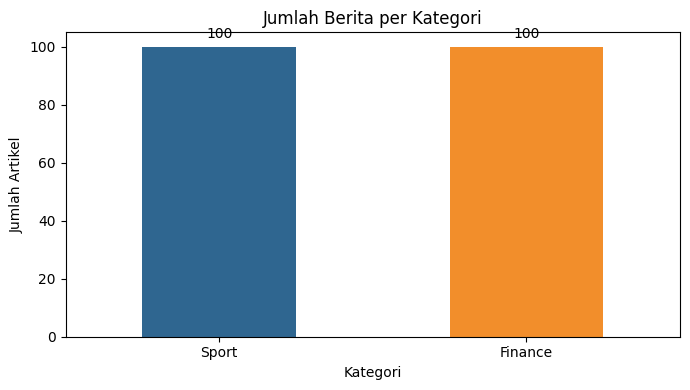

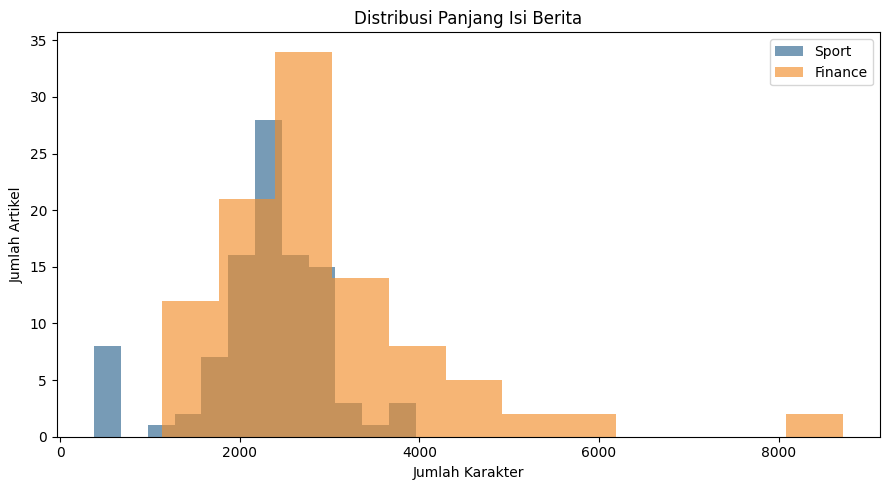

<Figure size 700x400 with 0 Axes>

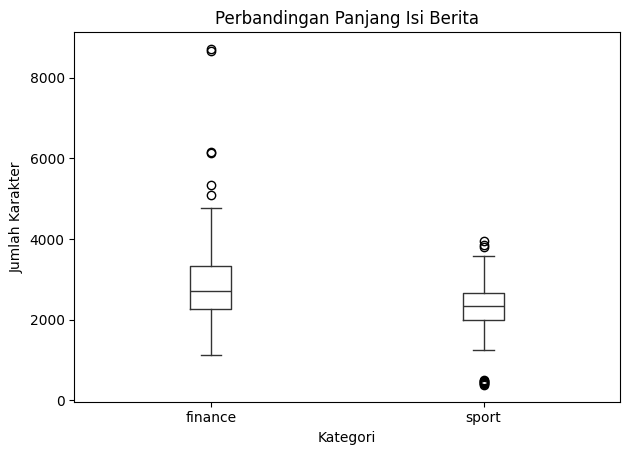

Kata yang paling sering muncul setelah stopword removal:


,sport,finance
motogp,448,0
marquez,324,0
aragon,286,0
marc,261,0
balapan,162,0
martin,144,0
wib,138,169
indonesia,133,197
bezzecchi,128,0
posisi,120,0


In [15]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Ringkasan statistik panjang teks per kategori.
ringkasan_teks = dataset.groupby("label")["panjang_teks"].agg(
    jumlah="count",
    rata_rata="mean",
    median="median",
    minimum="min",
    maksimum="max",
).round(0)
print("Statistik panjang isi berita:")
display(ringkasan_teks)

# Grafik 1: jumlah artikel pada setiap label.
jumlah_label = dataset["label"].value_counts().reindex(["sport", "finance"])
plt.figure(figsize=(7, 4))
ax = jumlah_label.plot(kind="bar", color=["#2f6690", "#f28e2b"])
ax.set_title("Jumlah Berita per Kategori")
ax.set_xlabel("Kategori")
ax.set_ylabel("Jumlah Artikel")
ax.set_xticklabels(["Sport", "Finance"], rotation=0)
for bar in ax.patches:
    ax.annotate(
        f"{int(bar.get_height())}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center", va="bottom", xytext=(0, 4), textcoords="offset points",
    )
plt.tight_layout()
plt.show()

# Grafik 2: distribusi panjang isi berita.
plt.figure(figsize=(9, 5))
for label, color in [("sport", "#2f6690"), ("finance", "#f28e2b")]:
    plt.hist(
        dataset.loc[dataset["label"] == label, "panjang_teks"],
        bins=12,
        alpha=0.65,
        label=label.title(),
        color=color,
    )
plt.title("Distribusi Panjang Isi Berita")
plt.xlabel("Jumlah Karakter")
plt.ylabel("Jumlah Artikel")
plt.legend()
plt.tight_layout()
plt.show()

# Grafik 3: boxplot untuk membandingkan panjang teks antar kategori.
plt.figure(figsize=(7, 4))
dataset.boxplot(column="panjang_teks", by="label", grid=False, color="#333333")
plt.suptitle("")
plt.title("Perbandingan Panjang Isi Berita")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Karakter")
plt.tight_layout()
plt.show()

# Tabel kata yang sering muncul sebagai gambaran topik awal.
stopwords_id = {
    "yang", "dan", "di", "ke", "dari", "ini", "itu", "untuk", "dengan",
    "pada", "dalam", "atau", "juga", "akan", "ada", "sebagai", "lebih",
    "sudah", "telah", "tidak", "karena", "oleh", "saat", "hingga", "dapat",
    "bisa", "jadi", "para", "nya", "ia", "tak", "tersebut", "mereka",
    "tautan", "disalin", "artikel", "baca", "saya", "selengkapnya", "detik",
}


def kata_teratas(label, jumlah=10):
    teks = dataset.loc[dataset["label"] == label, "isi_berita"].str.lower()
    kata = re.findall(r"[a-zA-Z]{3,}", " ".join(teks))
    kata = [item for item in kata if item not in stopwords_id]
    return Counter(kata).most_common(jumlah)


frekuensi_kata = pd.DataFrame({
    "sport": dict(kata_teratas("sport")),
    "finance": dict(kata_teratas("finance")),
}).fillna(0).astype(int)
print("Kata yang paling sering muncul setelah stopword removal:")
display(frekuensi_kata.sort_values(["sport", "finance"], ascending=False).head(10))

## Preprocessing Teks dan Perhitungan Kata Unik

Pada bagian ini, teks dari 200 artikel dipersiapkan sebelum dianalisis jumlah kata uniknya.

### Apa yang dilakukan?

1. **Tokenisasi**: memecah teks panjang menjadi kata-kata kecil yang disebut token.
2. **Lowercase**: mengubah semua huruf menjadi huruf kecil, sehingga `Indonesia` dan `indonesia` dihitung sebagai kata yang sama.
3. **Penyaringan token**: hanya mengambil token yang terdiri dari huruf dan memiliki minimal 3 karakter. Tanda baca, angka, dan kata sangat pendek seperti `di` tidak dihitung.
4. **Penggabungan teks**: seluruh isi berita digabung untuk mengetahui kosakata dari semua artikel.
5. **Perhitungan kata unik**: `set()` menghapus kata yang berulang, sehingga yang dihitung hanya kata berbeda.
6. **Pengelompokan kategori**: proses yang sama dilakukan untuk artikel `sport` dan `finance` agar keduanya dapat dibandingkan.

### Mengapa ada dua hasil?

- **Sebelum stopword removal**: semua kata yang lolos tokenisasi dihitung, termasuk kata umum.
- **Setelah stopword removal**: kata umum seperti `yang`, `dan`, `di`, dan `untuk` dihapus menggunakan `stopwords_id`. Hasil ini lebih membantu untuk melihat kosakata yang berkaitan dengan topik berita.

Jadi, kode setelah bagian ini bukan hanya menghitung frekuensi kemunculan kata, tetapi juga menghitung banyaknya kosakata berbeda dalam dataset.

In [16]:
import sys
print(sys.executable)

d:\data aplikasi\Python311\python.exe


In [17]:
%pip install Sastrawi

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Setup Sastrawi Stemmer (opsional: ubah USE_STEMMING = True jika ingin mengaktifkan stemming)
USE_STEMMING = False
factory = StemmerFactory()
stemmer = factory.create_stemmer()

stopwords_id = {
    "yang", "dan", "di", "ke", "dari", "ini", "itu", "untuk", "dengan",
    "pada", "dalam", "atau", "juga", "akan", "ada", "sebagai", "lebih",
    "sudah", "telah", "tidak", "karena", "oleh", "saat", "hingga", "dapat",
    "bisa", "jadi", "para", "nya", "ia", "tak", "tersebut", "mereka",
    "tautan", "disalin", "artikel", "baca", "saya", "selengkapnya", "detik",
}

# Preprocessing: Menghilangkan angka dan tanda baca (hanya menyisakan huruf alfabet dan spasi)
def bersihkan_simbol(teks):
    return re.sub(r"[^a-zA-Z\s]", " ", str(teks))

def tokenisasi(teks, use_stemming=USE_STEMMING):
    teks_bersih = bersihkan_simbol(teks)
    tokens = re.findall(r"[a-zA-Z]{3,}", teks_bersih.lower())
    if use_stemming:
        return [stemmer.stem(kata) for kata in tokens]
    return tokens

semua_token = tokenisasi(" ".join(dataset["isi_berita"].fillna("")))
token_per_label = {
    label: tokenisasi(" ".join(dataset.loc[dataset["label"] == label, "isi_berita"].fillna("")))
    for label in ["sport", "finance"]
}

ringkasan_kosakata = pd.DataFrame([
    {
        "cakupan": "Semua artikel",
        "jumlah_artikel": len(dataset),
        "total_kemunculan_kata": len(semua_token),
        "jumlah_kata_unik": len(set(semua_token)),
    },
    *[
        {
            "cakupan": label.title(),
            "jumlah_artikel": int((dataset["label"] == label).sum()),
            "total_kemunculan_kata": len(tokens),
            "jumlah_kata_unik": len(set(tokens)),
        }
        for label, tokens in token_per_label.items()
    ],
])

print("Ringkasan kata sebelum stopword removal:")
display(ringkasan_kosakata)

# Kata unik setelah stopword removal lebih representatif untuk melihat kosakata topik.
token_tanpa_stopword = [kata for kata in semua_token if kata not in stopwords_id]
token_tanpa_stopword_per_label = {
    label: [kata for kata in tokens if kata not in stopwords_id]
    for label, tokens in token_per_label.items()
}

ringkasan_setelah_stopword = pd.DataFrame([
    {
        "cakupan": "Semua artikel",
        "total_kemunculan_kata": len(token_tanpa_stopword),
        "jumlah_kata_unik": len(set(token_tanpa_stopword)),
    },
    *[
        {
            "cakupan": label.title(),
            "total_kemunculan_kata": len(tokens),
            "jumlah_kata_unik": len(set(tokens)),
        }
        for label, tokens in token_per_label.items()
    ],
])

print("Ringkasan kata setelah stopword removal:")
display(ringkasan_setelah_stopword)

print("10 kata unik paling sering muncul pada seluruh artikel setelah stopword removal:")
display(pd.DataFrame(Counter(token_tanpa_stopword).most_common(10), columns=["kata", "frekuensi"]))


Ringkasan kata sebelum stopword removal:


,cakupan,jumlah_artikel,total_kemunculan_kata,jumlah_kata_unik
0,Semua artikel,200,66902,6783
1,Sport,100,29607,3698
2,Finance,100,37295,4572


Ringkasan kata setelah stopword removal:


,cakupan,total_kemunculan_kata,jumlah_kata_unik
0,Semua artikel,54969,6746
1,Sport,29607,3698
2,Finance,37295,4572


10 kata unik paling sering muncul pada seluruh artikel setelah stopword removal:


,kata,frekuensi
0,motogp,448
1,indonesia,330
2,marquez,324
3,wib,307
4,aragon,286
5,jakarta,270
6,marc,261
7,menjadi,254
8,anda,217
9,kami,206


## Tahap 1: Membentuk Dokumen Token

Pada tahap ini, setiap isi berita diubah menjadi daftar kata.

- Simbol seperti `?`, `/`, dan `.` dibuang.
- Semua huruf diubah menjadi lowercase.
- Kata umum dalam `stopwords_id` diabaikan.
- Hasilnya disimpan dalam variabel `dokumen_token`.

Contoh sederhana: teks `Harga saham naik!` menjadi token `harga`, `saham`, dan `naik`.

In [19]:
import json
from collections import Counter

import numpy as np

# Mengubah isi berita menjadi daftar kata bersih.
dokumen_token = [
    [kata for kata in tokenisasi(teks) if kata not in stopwords_id]
    for teks in dataset["isi_berita"].fillna("")
]

print(f"Jumlah dokumen: {len(dokumen_token)}")
print(f"Contoh jumlah kata pada dokumen pertama: {len(dokumen_token[0])}")

Jumlah dokumen: 200
Contoh jumlah kata pada dokumen pertama: 396


## Tahap 2: Membagi Data Training dan Testing

Data dibagi menjadi dua bagian:

- **Training**: 160 berita, terdiri dari 80 `sport` dan 80 `finance`.
- **Testing**: 40 berita, terdiri dari 20 `sport` dan 20 `finance`.

Data training dipakai untuk membangun vocabulary dan nilai IDF. Data testing dipakai untuk melihat apakah pola yang dipelajari dapat digunakan pada berita yang belum dipakai saat pembelajaran.

In [20]:
# Pembagian data: 160 training dan 40 testing.
indeks_training = (
    dataset.index[dataset["label"] == "sport"][:80].tolist()
    + dataset.index[dataset["label"] == "finance"][:80].tolist()
)
indeks_testing = [indeks for indeks in dataset.index if indeks not in indeks_training]

print(f"Training: {len(indeks_training)} berita")
print(f"Testing: {len(indeks_testing)} berita")

Training: 160 berita
Testing: 40 berita


## Tahap 3: Vocabulary dan IDF

**Vocabulary** adalah kumpulan semua kata unik yang ditemukan pada data training. Setiap kata menjadi satu fitur atau satu posisi dalam vektor.

IDF (*Inverse Document Frequency*) mengukur seberapa jarang sebuah kata muncul pada seluruh dokumen:

$$
IDF(t) = \log\left(\frac{1 + N}{1 + DF(t)}\right) + 1
$$

`N` adalah jumlah dokumen training, sedangkan `DF(t)` adalah jumlah dokumen yang mengandung kata `t`. Kata yang muncul di banyak berita mendapat bobot lebih kecil karena kurang membedakan kategori.

In [21]:
# Vocabulary dan nilai IDF dihitung dari data training.
vocabulary = sorted({
    kata
    for indeks in indeks_training
    for kata in dokumen_token[indeks]
})
kolom_kata = {kata: posisi for posisi, kata in enumerate(vocabulary)}
jumlah_dokumen = len(indeks_training)
document_frequency = np.zeros(len(vocabulary), dtype=float)

for indeks in indeks_training:
    posisi_kata = {kolom_kata[kata] for kata in dokumen_token[indeks]}
    document_frequency[list(posisi_kata)] += 1

idf = np.log((1 + jumlah_dokumen) / (1 + document_frequency)) + 1

print(f"Jumlah kata unik: {len(vocabulary)}")
print(f"Panjang vektor setiap berita: {len(idf)}")

Jumlah kata unik: 5842
Panjang vektor setiap berita: 5842


## Tahap 4: Menghitung Nilai TF-IDF

TF (*Term Frequency*) mengukur seberapa sering kata muncul dalam satu berita:

$$
TF(t,d) = \frac{\text{jumlah kemunculan kata } t}{\text{jumlah seluruh kata dalam dokumen } d}
$$

Nilai TF-IDF diperoleh dari:

$$
TFIDF(t,d) = TF(t,d) \times IDF(t)
$$

Nilai besar berarti kata tersebut cukup sering muncul pada berita tertentu, tetapi tidak muncul pada terlalu banyak berita lain. Setelah dihitung, setiap berita menjadi satu vektor angka dengan panjang yang sama, yaitu sebanyak kata dalam vocabulary.

In [22]:
# Menghitung TF-IDF untuk satu dokumen.
def hitung_tfidf(indeks):
    hitungan = Counter(
        kata for kata in dokumen_token[indeks]
        if kata in kolom_kata
    )
    vektor = np.zeros(len(vocabulary), dtype=float)
    total_kata = sum(hitungan.values())

    if total_kata:
        for kata, jumlah in hitungan.items():
            posisi = kolom_kata[kata]
            tf = jumlah / total_kata
            vektor[posisi] = tf * idf[posisi]

    norma = np.linalg.norm(vektor)
    return vektor / norma if norma else vektor

matriks_tfidf = np.vstack([
    hitung_tfidf(indeks)
    for indeks in dataset.index
])

print(f"Bentuk matriks TF-IDF: {matriks_tfidf.shape}")

Bentuk matriks TF-IDF: (200, 5842)


## Tahap 5: Membentuk Dataset Vektor

Pada tahap ini, hasil TF-IDF disusun dalam dua bentuk:

1. `dataset_vektor`: berisi `id`, `isi_berita`, dan `label`. Kolom `isi_berita` berisi dictionary kata dan nilai TF-IDF.
2. `dataset_tfidf`: berisi satu kolom untuk setiap kata dalam vocabulary. Nilai setiap baris adalah nilai TF-IDF berita tersebut.

Label teks diubah menjadi angka agar dapat digunakan dalam proses klasifikasi:

- `sport = 1`
- `finance = 2`
# Menyimpan hasil TF-IDF ke CSV
dataset_tfidf.to_csv("hasil_tfidf.csv", index=False)
print("Data TF-IDF berhasil disimpan ke hasil_tfidf.csv")


In [23]:
# Membuat dataset dengan isi_berita berupa dictionary kata dan nilai TF-IDF.
import json

label_numerik = dataset["label"].map({"sport": 1, "finance": 2}).astype(int)
dataset_vektor = pd.DataFrame({
    "id": dataset["id"],
    "isi_berita": [
        json.dumps({
            kata: round(float(nilai), 8)
            for kata, nilai in zip(vocabulary, vektor)
            if nilai > 0
        })
        for vektor in matriks_tfidf
    ],
    "label": label_numerik,
})

dataset_tfidf = pd.DataFrame(matriks_tfidf, columns=vocabulary)
if "label" in dataset_tfidf.columns:
    dataset_tfidf.rename(columns={"label": "kata_label"}, inplace=True)
if "id" in dataset_tfidf.columns:
    dataset_tfidf.rename(columns={"id": "kata_id"}, inplace=True)
dataset_tfidf.insert(0, "label", label_numerik.to_numpy())
dataset_tfidf.insert(0, "id", dataset["id"].to_numpy())

# Menyimpan hasil TF-IDF ke CSV
dataset_tfidf.to_csv("hasil_tfidf.csv", index=False)
print("Data hasil TF-IDF berhasil disimpan ke hasil_tfidf.csv")

# Menampilkan hasil perhitungan TF-IDF dalam bentuk tabel matriks
print(f"Ukuran DataFrame TF-IDF: {dataset_tfidf.shape}")
sampel = dataset_tfidf.iloc[:10, :12] # Menampilkan 10 baris pertama dan 12 kolom pertama (id, label, + 10 kata)
styled_sampel = sampel.style.background_gradient(cmap="Blues", axis=None, subset=sampel.columns[2:]).format("{:.3f}", subset=sampel.columns[2:])
display(styled_sampel)


Data hasil TF-IDF berhasil disimpan ke hasil_tfidf.csv
Ukuran DataFrame TF-IDF: (200, 5844)


,id,label,aau,abadi,abdul,abdullah,abraham,absen,absennya,absorber,abu,abullah
0,SP001,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.232,0.000
1,SP002,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,SP003,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,SP004,1,0.000,0.000,0.000,0.000,0.048,0.000,0.000,0.000,0.000,0.000
4,SP005,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,SP006,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
6,SP007,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
7,SP008,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
8,SP009,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
9,SP010,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


## Reduksi Dimensi dengan PCA

Tahap ini bertujuan untuk mengurangi jumlah dimensi (kolom) dari matriks TF-IDF agar lebih padat, namun tetap menyimpan sebagian besar informasi/varians dari data aslinya.

In [24]:
from sklearn.decomposition import PCA
import pandas as pd

# Mengambil matriks TF-IDF murni (tanpa id dan label)
X = matriks_tfidf

# Melakukan PCA menjadi 20 komponen
pca = PCA(n_components=20)

X_pca = pca.fit_transform(X)

# Membuat DataFrame hasil PCA dan menyambungkan kembali id & label
df_pca = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
)

df_pca.insert(0, "label", dataset_tfidf["label"])
df_pca.insert(0, "id", dataset_tfidf["id"])

# Menampilkan jumlah kolom dan baris sebelum dan sesudah reduksi
print("=== Perbandingan Dimensi (Baris, Kolom) ===")

print(f"Sebelum di-reduksi (TF-IDF asli): {X.shape}")
print(f"Sesudah di-reduksi (PCA): {X_pca.shape}")

# Export PCA ke CSV
df_pca.to_csv("hasil_pca2.csv", index=False)

print("\nData hasil PCA berhasil disimpan ke hasil_pca2.csv")

display(df_pca.head())

=== Perbandingan Dimensi (Baris, Kolom) ===
Sebelum di-reduksi (TF-IDF asli): (200, 5842)
Sesudah di-reduksi (PCA): (200, 20)

Data hasil PCA berhasil disimpan ke hasil_pca2.csv


,id,label,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,SP001,1,-0.129766,-0.104856,0.144100,-0.038767,0.003940,-0.027654,-0.010119,0.053491,...,0.070987,0.018699,-0.099495,0.185228,0.020122,-0.062782,-0.012332,0.016350,0.057801,-0.090821
1,SP002,1,-0.120188,0.016481,-0.104996,0.409287,-0.174138,-0.030601,-0.464780,-0.157465,...,-0.003149,0.032562,0.047867,0.023245,0.044246,-0.024013,-0.140798,0.056706,-0.121689,0.127085
2,SP003,1,-0.090251,0.022549,-0.093129,0.377059,-0.167748,-0.032326,-0.396537,-0.124921,...,-0.047713,0.037429,0.034680,0.030886,0.029922,-0.017414,-0.101279,0.048340,-0.073949,0.122581
3,SP004,1,-0.093736,0.059198,-0.083081,0.387749,-0.160254,-0.025310,-0.398755,-0.137537,...,-0.005237,0.040872,0.045004,0.027435,0.049753,-0.005994,-0.091727,0.014186,-0.045001,0.109394
4,SP005,1,-0.117050,0.029496,-0.091153,0.380017,-0.167424,-0.010019,-0.432904,-0.144517,...,-0.009402,0.046312,0.034215,0.038315,0.030507,-0.020396,-0.169828,0.069200,-0.147501,0.162903


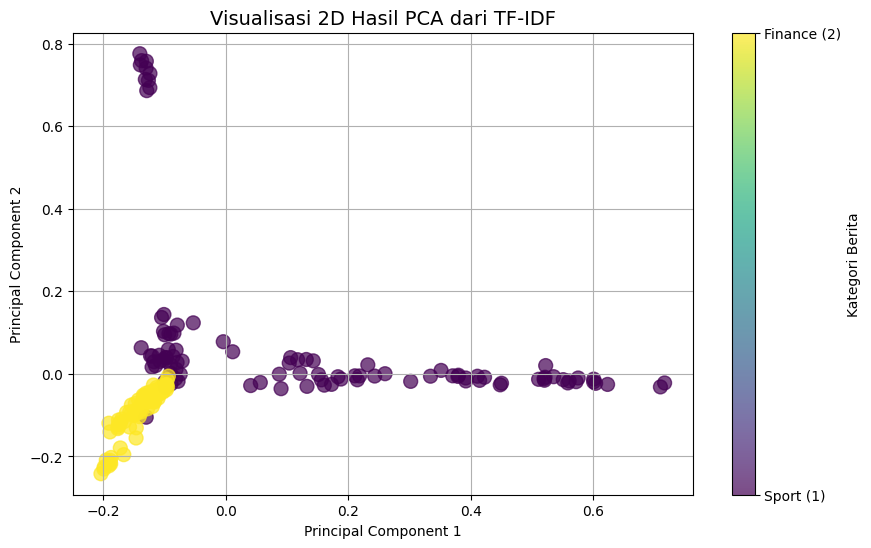

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_pca['PC1'], df_pca['PC2'], 
    c=df_pca['label'], cmap='viridis', 
    s=100, alpha=0.7
)

plt.title('Visualisasi 2D Hasil PCA dari TF-IDF', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Adding a legend
cbar = plt.colorbar(scatter, ticks=[1, 2])
cbar.ax.set_yticklabels(['Sport (1)', 'Finance (2)'])
cbar.set_label('Kategori Berita')

plt.grid(True)
plt.show()


## Tahap 6: Klasifikasi Berbasis Centroid

Centroid adalah rata-rata posisi vektor dari seluruh berita dalam satu kategori. Notebook menghitung centroid untuk `sport` dan `finance`, lalu mengukur jarak setiap berita testing ke kedua centroid.

Berita diberi label kategori dengan jarak yang lebih dekat. Karena vektor TF-IDF sudah dinormalisasi, jarak tersebut dapat digunakan untuk membandingkan kemiripan isi berita secara numerik.

In [26]:
# Klasifikasi sederhana menggunakan jarak centroid TF-IDF.
centroid_sport = matriks_tfidf[indeks_training][
    label_numerik.iloc[indeks_training].to_numpy() == 1
].mean(axis=0)
centroid_finance = matriks_tfidf[indeks_training][
    label_numerik.iloc[indeks_training].to_numpy() == 2
].mean(axis=0)

distance_sport = np.linalg.norm(
    matriks_tfidf[indeks_testing] - centroid_sport,
    axis=1,
)
distance_finance = np.linalg.norm(
    matriks_tfidf[indeks_testing] - centroid_finance,
    axis=1,
)
prediksi_testing = np.where(distance_sport <= distance_finance, 1, 2)
akurasi = (
    prediksi_testing == label_numerik.iloc[indeks_testing].to_numpy()
).mean()

print(f"Akurasi testing: {akurasi:.2%}")

Akurasi testing: 82.50%


## Kesimpulan

Proses pengolahan 200 berita berhasil dilakukan dari teks mentah sampai menjadi vektor numerik yang dapat digunakan untuk klasifikasi.

- Simbol dibuang sebelum tokenisasi agar kata dihitung secara konsisten.
- Ditemukan **6.786 kata unik** sebelum stopword removal dan **6.749 kata unik** setelah stopword removal.
- Data dibagi menjadi **160 berita training** dan **40 berita testing**.
- Vocabulary dari data training berisi **5.845 kata unik**.
- Setiap berita diubah menjadi vektor TF-IDF dengan panjang **5.845 fitur**.
- Label kategori diubah menjadi angka: `sport = 1` dan `finance = 2`.
- Klasifikasi berbasis jarak centroid menghasilkan akurasi **82,50%** pada data testing.

Artinya, TF-IDF berhasil mengubah isi berita menjadi representasi angka yang cukup informatif untuk membedakan berita sport dan finance. Akurasi 82,50% menunjukkan bahwa pendekatan ini sudah dapat mengenali sebagian besar kategori berita, walaupun masih ada beberapa berita yang salah diklasifikasikan.